<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


Top industries by respondent count:


Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Name: count, dtype: int64

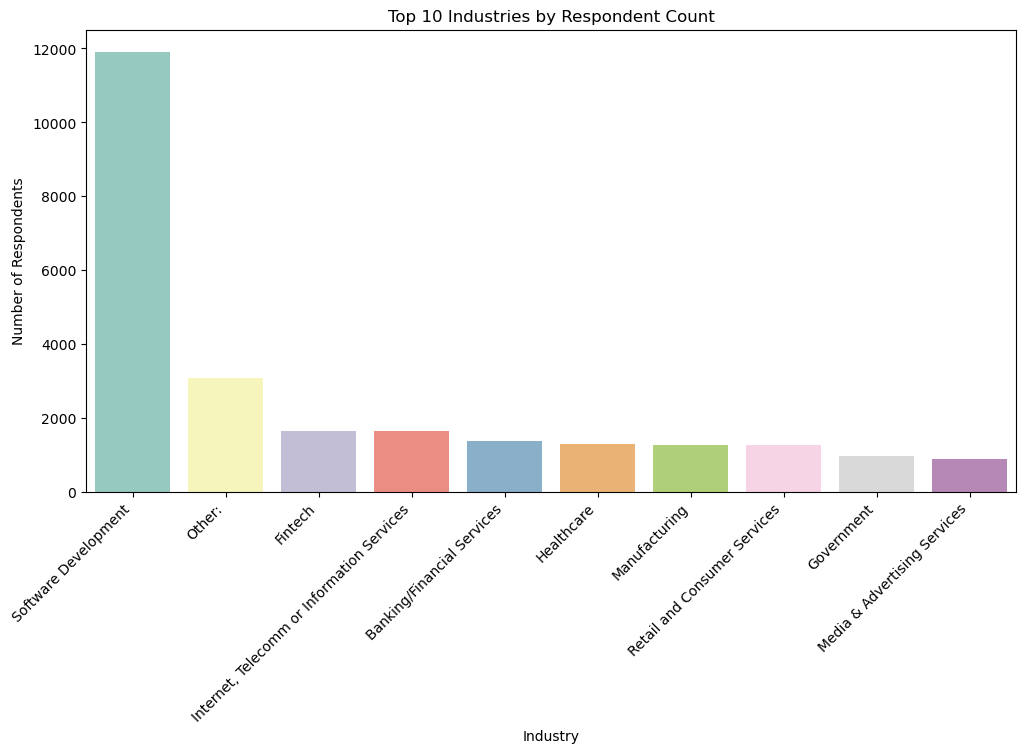

In [4]:
##Write your code here

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Count respondents per industry
industry_counts = df['Industry'].value_counts().sort_values(ascending=False)

# Display top industries
print("Top industries by respondent count:")
display(industry_counts.head(10))

# Step 2: Plot bar chart for top industries
plt.figure(figsize=(12,6))
sns.barplot(x=industry_counts.index[:10], y=industry_counts.values[:10], palette="Set3")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Industries by Respondent Count")
plt.xlabel("Industry")
plt.ylabel("Number of Respondents")
plt.show()


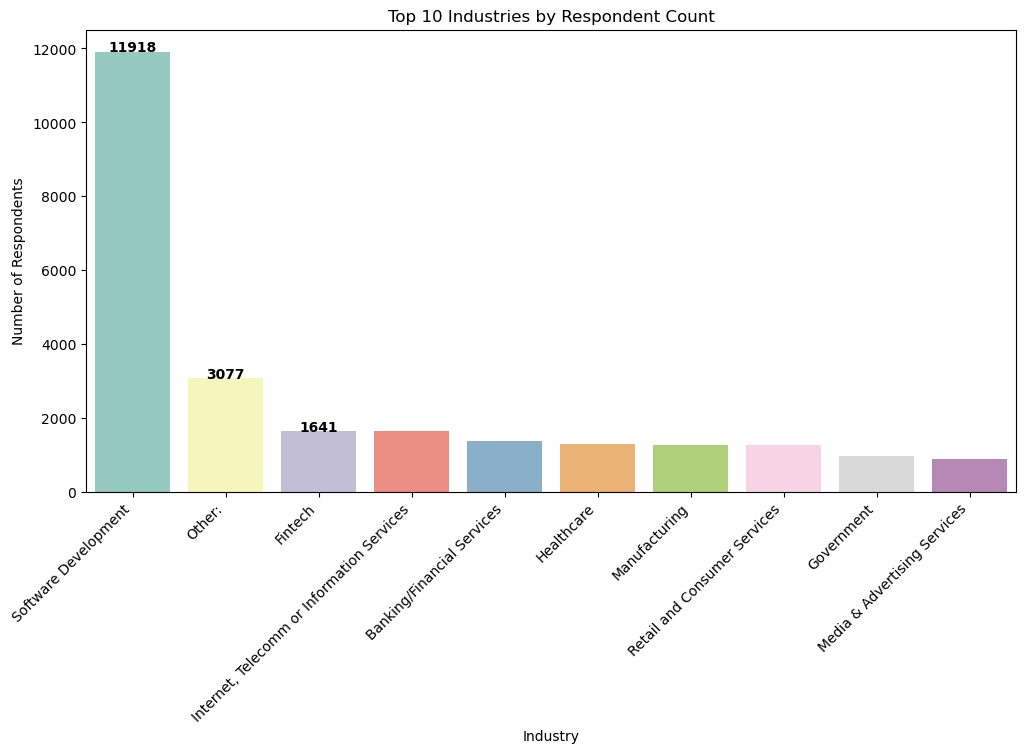

In [7]:
#This code highlights notable trends.
plt.figure(figsize=(12,6))
sns.barplot(x=industry_counts.index[:10], y=industry_counts.values[:10], palette="Set3")

# Annotate top 3 industries
for i, val in enumerate(industry_counts.values[:3]):
    plt.text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Industries by Respondent Count")
plt.xlabel("Industry")
plt.ylabel("Number of Respondents")
plt.show()


<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [9]:
##Write your code here

import pandas as pd

# Step 1: Basic statistics
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print(f"Mean Compensation: {mean_comp:.2f}")
print(f"Median Compensation: {median_comp:.2f}")
print(f"Standard Deviation: {std_comp:.2f}")

# Step 2: Define threshold for high compensation (e.g., 3 SD above mean)
high_threshold = mean_comp + 3 * std_comp
print(f"High Compensation Threshold (Mean + 3*SD): {high_threshold:.2f}")

# Step 3: Identify high compensation respondents
high_comp_outliers = df[df['ConvertedCompYearly'] > high_threshold]

print(f"\nNumber of high compensation outliers: {high_comp_outliers.shape[0]}")
display(high_comp_outliers[['ConvertedCompYearly', 'Employment', 'Country', 'EdLevel']])


Mean Compensation: 86155.29
Median Compensation: 65000.00
Standard Deviation: 186756.97
High Compensation Threshold (Mean + 3*SD): 646426.21

Number of high compensation outliers: 89


,ConvertedCompYearly,Employment,Country,EdLevel
529,650000.0,"Employed, full-time",United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
828,1000000.0,"Employed, full-time",United States of America,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"
1932,945000.0,"Employed, full-time",United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
2171,750000.0,"Employed, full-time",United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
2187,2000000.0,"Employed, full-time",Gabon,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
...,...,...,...,...
38219,1000000.0,"Employed, full-time",Poland,Some college/university study without earning ...
39643,1300000.0,"Employed, full-time",United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
40066,800000.0,"Employed, full-time",United States of America,Some college/university study without earning ...
40952,750000.0,"Employed, full-time",United States of America,Some college/university study without earning ...


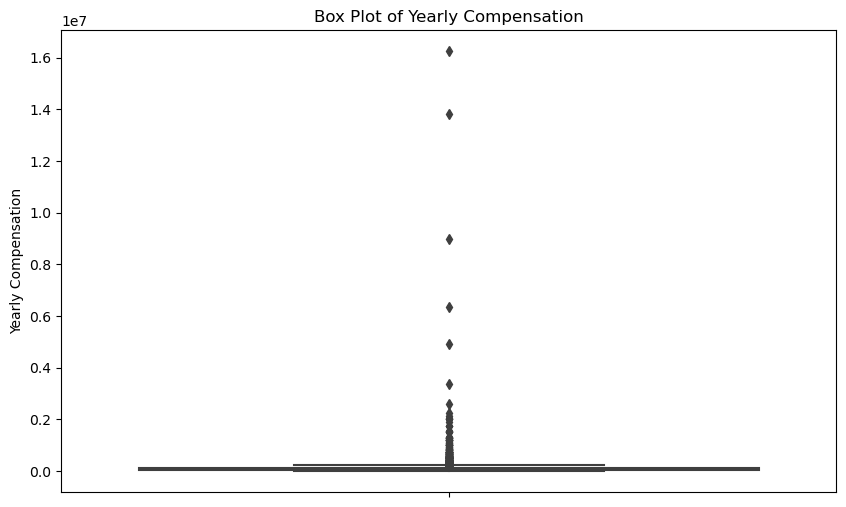

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y='ConvertedCompYearly')
plt.ylabel('Yearly Compensation')
plt.title('Box Plot of Yearly Compensation')
plt.show()

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1 (25th percentile): 32712.0
Q3 (75th percentile): 107971.5
IQR (Q3 - Q1): 75259.5
Lower Bound: -80177.25
Upper Bound: 220860.75
Number of outliers detected: 978


,ConvertedCompYearly,Employment,Country,EdLevel
428,230000.0,"Employed, full-time",United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
456,300000.0,"Employed, full-time",United States of America,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)"
461,254425.0,"Employed, full-time",Canada,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"
529,650000.0,"Employed, full-time",United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
545,400000.0,"Employed, full-time",United States of America,"Secondary school (e.g. American high school, G..."
...,...,...,...,...
40952,750000.0,"Employed, full-time",United States of America,Some college/university study without earning ...
41000,235000.0,"Employed, full-time",United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
41001,260000.0,"Employed, full-time;Student, part-time",United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
41027,700000.0,"Independent contractor, freelancer, or self-em...",United States of America,Some college/university study without earning ...


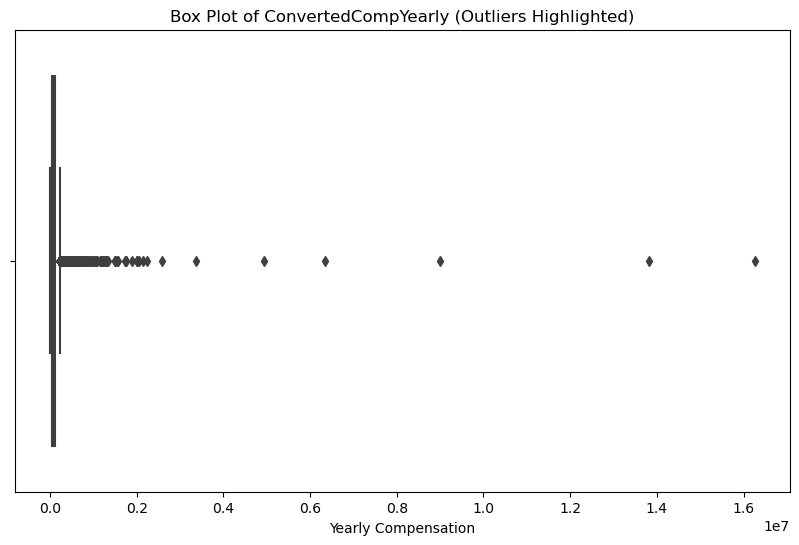

In [17]:
##Write your code here
#Step 1: Calculate the IQR
#IQR=Q3−Q1
'''Where:

Q1 (25th percentile) → 25% of values are below this point

Q3 (75th percentile) → 75% of values are below this point'''
# Calculate Q1 and Q3

Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Q3 - Q1): {IQR}")


#Step 2: Determine outlier bounds
#Outliers are typically defined as points that lie 1.5 * IQR below Q1 or above Q3:

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

#Step 3: Identify outliers
#We can now filter the dataset to find rows that are below the lower bound or above the upper bound:

# Identify outliers
outliers = df[(df['ConvertedCompYearly'] < lower_bound) | 
              (df['ConvertedCompYearly'] > upper_bound)]

print(f"Number of outliers detected: {outliers.shape[0]}")
display(outliers[['ConvertedCompYearly', 'Employment', 'Country', 'EdLevel']])

#Step 4: Visualize outliers using a box plot

#A box plot is perfect for visualizing IQR-based outliers:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x=df['ConvertedCompYearly'])
plt.title("Box Plot of ConvertedCompYearly (Outliers Highlighted)")
plt.xlabel("Yearly Compensation")
plt.show()

In [19]:
# Step 1: Sort outliers by compensation in descending order
top_high_comp = outliers.sort_values(by='ConvertedCompYearly', ascending=False).head(5)

# Step 2: Select relevant columns
top_high_comp_summary = top_high_comp[['ConvertedCompYearly', 'Employment', 'Country', 'EdLevel']]

# Step 3: Display the summary table
print("Top 5 High Compensation Outliers:")
display(top_high_comp_summary)


Top 5 High Compensation Outliers:


,ConvertedCompYearly,Employment,Country,EdLevel
15837,16256603.0,"Independent contractor, freelancer, or self-em...",Ethiopia,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
12723,13818022.0,"Employed, full-time;Independent contractor, fr...",South Africa,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)"
28379,9000000.0,"Employed, full-time",Taiwan,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)"
17593,6340564.0,"Employed, full-time",Brazil,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
17672,4936778.0,"Employed, full-time",Ukraine,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)"


<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [21]:
##Write your code here

# Step 1: Filter out rows that are NOT outliers
df_cleaned = df[(df['ConvertedCompYearly'] >= lower_bound) & 
                (df['ConvertedCompYearly'] <= upper_bound)].copy()

# Step 2: Validate the new DataFrame
print(f"Original dataset size: {df.shape[0]} rows")
print(f"Cleaned dataset size (outliers removed): {df_cleaned.shape[0]} rows")
print(f"Number of rows removed: {df.shape[0] - df_cleaned.shape[0]}")

# Optional: basic stats after removing outliers
print("\nStatistics after removing outliers:")
display(df_cleaned['ConvertedCompYearly'].describe())


Original dataset size: 65437 rows
Cleaned dataset size (outliers removed): 22457 rows
Number of rows removed: 42980

Statistics after removing outliers:


count     22457.000000
mean      71347.201897
std       51271.396445
min           1.000000
25%       32000.000000
50%       63694.000000
75%      101281.000000
max      220207.000000
Name: ConvertedCompYearly, dtype: float64

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [31]:
##Write your code here

age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None  # Or an appropriate value for missing data
}

df['AgeNumeric'] = df['Age'].map(age_mapping)

# Display the first few rows with the new column
display(df[['Age', 'AgeNumeric']].head())

# Check the data type of the new column
print("\nData type of 'AgeNumeric':", df['AgeNumeric'].dtype)


numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Compute the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Display the correlations of 'AgeNumeric' with other numerical columns
print("Correlations with AgeNumeric:")
display(correlation_matrix['AgeNumeric'].sort_values(ascending=False))


,Age,AgeNumeric
0,Under 18 years old,16.0
1,35-44 years old,39.5
2,45-54 years old,49.5
3,18-24 years old,21.0
4,18-24 years old,21.0



Data type of 'AgeNumeric': float64
Correlations with AgeNumeric:


AgeNumeric             1.000000
WorkExp                0.850655
ConvertedCompYearly    0.121512
JobSat                 0.069844
CompTotal             -0.002761
JobSatPoints_1        -0.027908
ResponseId            -0.037967
JobSatPoints_8        -0.046092
JobSatPoints_6        -0.050228
JobSatPoints_4        -0.076032
JobSatPoints_9        -0.081633
JobSatPoints_7        -0.082683
JobSatPoints_5        -0.101475
JobSatPoints_11       -0.107092
JobSatPoints_10       -0.114350
Name: AgeNumeric, dtype: float64

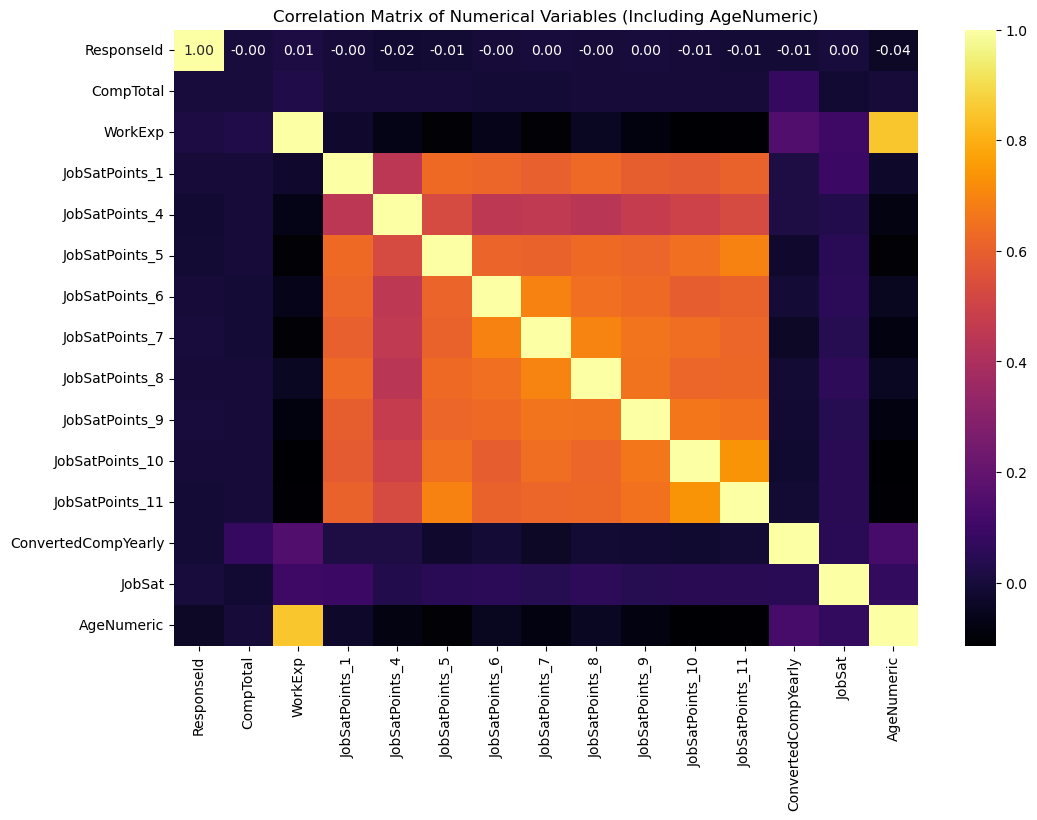

In [35]:

plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="inferno")
plt.title("Correlation Matrix of Numerical Variables (Including AgeNumeric)")
plt.show()


<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
